# Xie Decoder 2D Projection Analysis: GO vs STOP Trials

This notebook projects neural activity onto the **2D hidden layer** of the Xie decoder to visualize trial trajectories in the learned representational space.

**Key Analyses:**
1. Time-resolved projections onto both dimensions of the 2D hidden layer
2. 2D trajectory visualization for single trials and population averages
3. Dimension-wise analysis (Dim 1 vs Dim 2)
4. Population average trajectories in 2D space

**Session**: fi211025a (63 neurons)  
**SSD level**: 2 (~108ms)

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import joblib
import torch
import torch.nn as nn
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# Set style
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Define Xie Decoder Architecture

In [2]:
class XieDecoder(nn.Module):
    """Xie-style decoder with 2D hidden layer."""
    def __init__(self, n_neurons, hidden_dim=2, n_classes=2):
        super().__init__()
        self.n_neurons = n_neurons
        self.hidden_dim = hidden_dim
        self.n_classes = n_classes
        
        self.W = nn.Linear(n_neurons, hidden_dim, bias=True)
        self.M = nn.Linear(hidden_dim, n_classes, bias=False)
    
    def forward(self, x):
        h = self.W(x)
        logits = self.M(h)
        return logits, h
    
    def predict_proba(self, x):
        with torch.no_grad():
            logits, _ = self.forward(x)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    def predict(self, x):
        probs = self.predict_proba(x)
        return np.argmax(probs, axis=1)

print("✓ XieDecoder architecture defined")

✓ XieDecoder architecture defined


## 3. Load Prepared Data and Models

In [3]:
# Configuration
session_id = 'fi211025a'
ssd_num = 2

# Paths
data_dir = Path.cwd().parents[1] / 'data' / 'decoder_data'
models_dir = Path.cwd().parents[1] / 'data' / 'decoder_models'

# Load prepared data
data_file = data_dir / f'decoder_data_{session_id}_ssd{ssd_num}.pkl'
print(f"Loading data from: {data_file}")

with open(data_file, 'rb') as f:
    prepared_data = pickle.load(f)

epoch_defs = prepared_data['epoch_defs']
normalized_datasets = prepared_data['datasets']

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

print(f"\n✓ Prepared data loaded successfully!")
print(f"  Session: {session_id}")
print(f"  SSD level: {ssd_num}")

Loading data from: /home/barak/Projects/population-analysis/data/decoder_data/decoder_data_fi211025a_ssd2.pkl

✓ Prepared data loaded successfully!
  Session: fi211025a
  SSD level: 2


In [4]:
# Load trained Xie models
xie_models = {}

print("Loading trained Xie models...")

for direction in directions:
    dir_name = dir_map[direction].lower()
    
    # Load Xie Decoder
    xie_file = models_dir / f'xie_decoder_{session_id}_ssd{ssd_num}_{dir_name}.pt'
    checkpoint = torch.load(xie_file, map_location='cpu')
    
    n_neurons = checkpoint['n_neurons']
    hidden_dim = checkpoint['hidden_dim']
    model = XieDecoder(n_neurons, hidden_dim)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Extract W matrix (first layer weights)
    W_weights = model.W.weight.data.cpu().numpy()  # Shape: (hidden_dim, n_neurons)
    W_bias = model.W.bias.data.cpu().numpy()       # Shape: (hidden_dim,)
    
    xie_models[direction] = {
        'model': model,
        'W_weights': W_weights,
        'W_bias': W_bias,
        'history': checkpoint['history']
    }
    print(f"✓ Loaded Xie Decoder ({dir_map[direction]})")
    print(f"  W matrix shape: {W_weights.shape}")
    print(f"  W bias shape: {W_bias.shape}")

print("\n✓ All models loaded successfully!")

Loading trained Xie models...
✓ Loaded Xie Decoder (Right)
  W matrix shape: (2, 63)
  W bias shape: (2,)
✓ Loaded Xie Decoder (Left)
  W matrix shape: (2, 63)
  W bias shape: (2,)

✓ All models loaded successfully!


## 4. Load Full Session Data

In [5]:
# Load full cell_df to access spike times
cell_df_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data' / 'msn_fiona_cell_trial_data.pkl'
print(f"Loading cell_df from: {cell_df_path}")

cell_df = pd.read_pickle(cell_df_path)

# Filter to session
session_data = cell_df[cell_df['trial_session'] == session_id].copy()

print(f"✓ Loaded session {session_id}: {len(session_data)} cell-trial combinations")
print(f"  Unique cells: {session_data['cell_ID'].nunique()}")
print(f"  Unique trials: {session_data['trial_number'].nunique()}")

Loading cell_df from: /home/barak/Projects/population-analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Loaded session fi211025a: 33136 cell-trial combinations
  Unique cells: 63
  Unique trials: 685


---

# 5. Time-Resolved 2D Projection Function

In [6]:
def compute_time_resolved_2d_projection(session_data, trial_number, direction, 
                                       W_weights, W_bias, cell_ids, 
                                       train_mean, train_std,
                                       time_window=(-300, 400), bin_size=108, step_size=20):
    """
    Compute time-resolved projection of a trial onto the 2D hidden layer of Xie decoder.
    
    Parameters:
    -----------
    session_data : DataFrame
        Full session data with spike times
    trial_number : int
        Trial number to analyze
    direction : int
        Direction (0 or 180)
    W_weights : ndarray
        W matrix weights from Xie decoder (hidden_dim, n_neurons)
    W_bias : ndarray
        W matrix bias from Xie decoder (hidden_dim,)
    cell_ids : list
        Ordered list of cell IDs matching W_weights columns
    train_mean : ndarray
        Training mean for z-score normalization (n_neurons,)
    train_std : ndarray
        Training std for z-score normalization (n_neurons,)
    time_window : tuple
        (start, end) time relative to go_cue in ms
    bin_size : int
        Bin size in ms
    step_size : int
        Step size in ms
    
    Returns:
    --------
    time_bins : ndarray
        Start time of each bin
    projection_2d : ndarray
        2D projection at each time bin (n_bins, 2)
    """
    # Filter data for this trial and direction
    trial_data = session_data[
        (session_data['trial_number'] == trial_number) & 
        (session_data['dir'] == direction)
    ].copy()
    
    if len(trial_data) == 0:
        return None, None
    
    # Create time bins
    bin_edges = np.arange(time_window[0], time_window[1] + step_size, step_size)
    time_bins = bin_edges
    
    # Initialize firing rate matrix
    n_bins = len(time_bins)
    n_neurons = len(cell_ids)
    firing_rates = np.zeros((n_bins, n_neurons))
    
    # Compute firing rate for each neuron and time bin
    for neuron_idx, cell_id in enumerate(cell_ids):
        cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
        
        if len(cell_trial) == 0:
            continue
        
        # Get spike times and align to go_cue
        spike_times = cell_trial['neural_data'].iloc[0]
        go_cue_time = cell_trial['go_cue'].iloc[0]
        spike_times_rel = spike_times - go_cue_time
        
        if spike_times_rel is None or len(spike_times_rel) == 0:
            continue
        
        # Bin spikes
        for bin_idx in range(n_bins):
            bin_start = bin_edges[bin_idx]
            bin_end = bin_start + bin_size
            
            spikes_in_bin = np.sum((spike_times_rel >= bin_start) & 
                                   (spike_times_rel < bin_end))
            duration_sec = bin_size / 1000.0
            firing_rates[bin_idx, neuron_idx] = spikes_in_bin / duration_sec
    
    # Z-score normalization using training statistics
    firing_rates_normalized = (firing_rates - train_mean) / (train_std + 1e-10)
    
    # Project onto 2D hidden layer: h = X @ W^T + b
    # W_weights shape: (hidden_dim, n_neurons)
    # firing_rates_normalized shape: (n_bins, n_neurons)
    # Result shape: (n_bins, hidden_dim)
    projection_2d = firing_rates_normalized @ W_weights.T + W_bias
    
    return time_bins, projection_2d


print("✓ Time-resolved 2D projection function defined")

✓ Time-resolved 2D projection function defined


## 6. Select Exemplar Trials and Compute 2D Projections

In [7]:
# Select exemplar trials for each direction
exemplar_trials = {}

for direction in directions:
    # Get test trial numbers for GO trials
    test_meta = normalized_datasets[direction]['meta_test']
    go_test_trials = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    # Select first GO trial from test set as exemplar
    exemplar_go_trial = go_test_trials[0] if len(go_test_trials) > 0 else None
    
    # Get STOP trials for this direction
    stop_trials = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    # Select first STOP trial as exemplar
    exemplar_stop_trial = stop_trials[0] if len(stop_trials) > 0 else None
    
    # Get Xie model components
    W_weights = xie_models[direction]['W_weights']
    W_bias = xie_models[direction]['W_bias']
    cell_ids = normalized_datasets[direction]['cell_ids']
    
    # Get normalization statistics
    neuron_stats = normalized_datasets[direction]['neuron_stats']
    train_mean = neuron_stats['mean']
    train_std = neuron_stats['std']
    
    # Store information
    exemplar_trials[direction] = {
        'go_trial': exemplar_go_trial,
        'stop_trial': exemplar_stop_trial,
        'W_weights': W_weights,
        'W_bias': W_bias,
        'cell_ids': cell_ids,
        'train_mean': train_mean,
        'train_std': train_std
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Exemplar GO trial: {exemplar_go_trial}")
    print(f"  Exemplar STOP trial: {exemplar_stop_trial}")

print("\n✓ Exemplar trials selected")


Right Direction:
  Exemplar GO trial: 655
  Exemplar STOP trial: 393

Left Direction:
  Exemplar GO trial: 616
  Exemplar STOP trial: 84

✓ Exemplar trials selected


In [8]:
# Compute time-resolved 2D projections for exemplar trials
projection_results_2d = {}

BIN_SIZE = 108  # ms ; window from which to take avg spike rate
STEP_SIZE = 20  # ms ; step size from one bin start time to the next
TIME_WINDOW = (-100, 200)  # ms relative to go_cue

for direction in directions:
    info = exemplar_trials[direction]
    
    # Compute projection for GO trial
    go_time, go_proj_2d = compute_time_resolved_2d_projection(
        session_data,
        info['go_trial'],
        direction,
        info['W_weights'],
        info['W_bias'],
        info['cell_ids'],
        info['train_mean'],
        info['train_std'],
        time_window=TIME_WINDOW,
        bin_size=BIN_SIZE,
        step_size=STEP_SIZE
    )
    
    # Compute projection for STOP trial
    stop_time, stop_proj_2d = compute_time_resolved_2d_projection(
        session_data,
        info['stop_trial'],
        direction,
        info['W_weights'],
        info['W_bias'],
        info['cell_ids'],
        info['train_mean'],
        info['train_std'],
        time_window=TIME_WINDOW,
        bin_size=BIN_SIZE,
        step_size=STEP_SIZE
    )
    
    projection_results_2d[direction] = {
        'go_time': go_time,
        'go_proj_2d': go_proj_2d,  # Shape: (n_bins, 2)
        'stop_time': stop_time,
        'stop_proj_2d': stop_proj_2d  # Shape: (n_bins, 2)
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  GO trial 2D projection computed: {go_proj_2d.shape if go_proj_2d is not None else 'None'}")
    print(f"  STOP trial 2D projection computed: {stop_proj_2d.shape if stop_proj_2d is not None else 'None'}")

print("\n✓ Time-resolved 2D projections computed")


Right Direction:
  GO trial 2D projection computed: (16, 2)
  STOP trial 2D projection computed: (16, 2)

Left Direction:
  GO trial 2D projection computed: (16, 2)
  STOP trial 2D projection computed: (16, 2)

✓ Time-resolved 2D projections computed


---

# 7. Visualize: Dimension-Wise Time Course

## 7.1 Dimension 1 Time Course

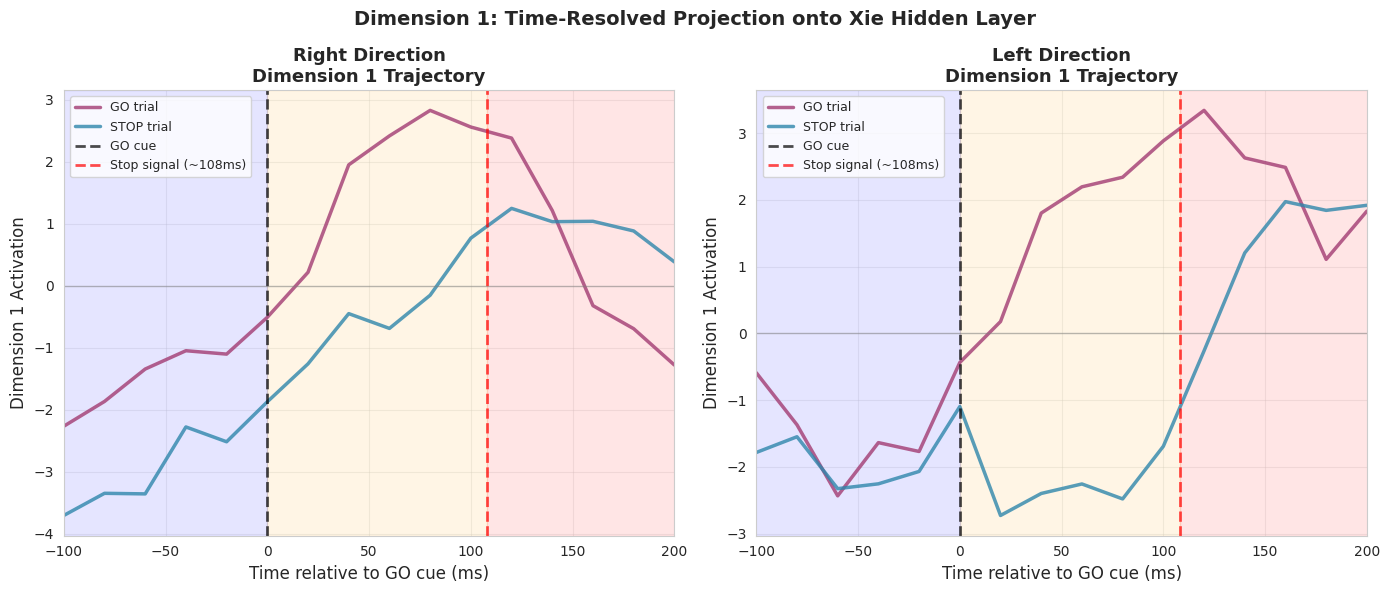

In [9]:
# Plot Dimension 1 time course for GO vs STOP trials
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get projection results
    go_time = projection_results_2d[direction]['go_time']
    go_proj_2d = projection_results_2d[direction]['go_proj_2d']
    stop_time = projection_results_2d[direction]['stop_time']
    stop_proj_2d = projection_results_2d[direction]['stop_proj_2d']
    
    # Extract Dimension 1 (index 0)
    go_dim1 = go_proj_2d[:, 0] if go_proj_2d is not None else None
    stop_dim1 = stop_proj_2d[:, 0] if stop_proj_2d is not None else None
    
    # Get mean_ssd
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Plot GO trial
    if go_dim1 is not None:
        ax.plot(go_time, go_dim1, linewidth=2.5, label='GO trial', 
                color='#A23B72', alpha=0.8)
    
    # Plot STOP trial
    if stop_dim1 is not None:
        ax.plot(stop_time, stop_dim1, linewidth=2.5, label='STOP trial', 
                color='#2E86AB', alpha=0.8)
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, 
               label='GO cue', alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, 
               label=f'Stop signal (~{mean_ssd:.0f}ms)', alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.1, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.1, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.1, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.1, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=12)
    ax.set_ylabel('Dimension 1 Activation', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nDimension 1 Trajectory', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle('Dimension 1: Time-Resolved Projection onto Xie Hidden Layer', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.2 Dimension 2 Time Course

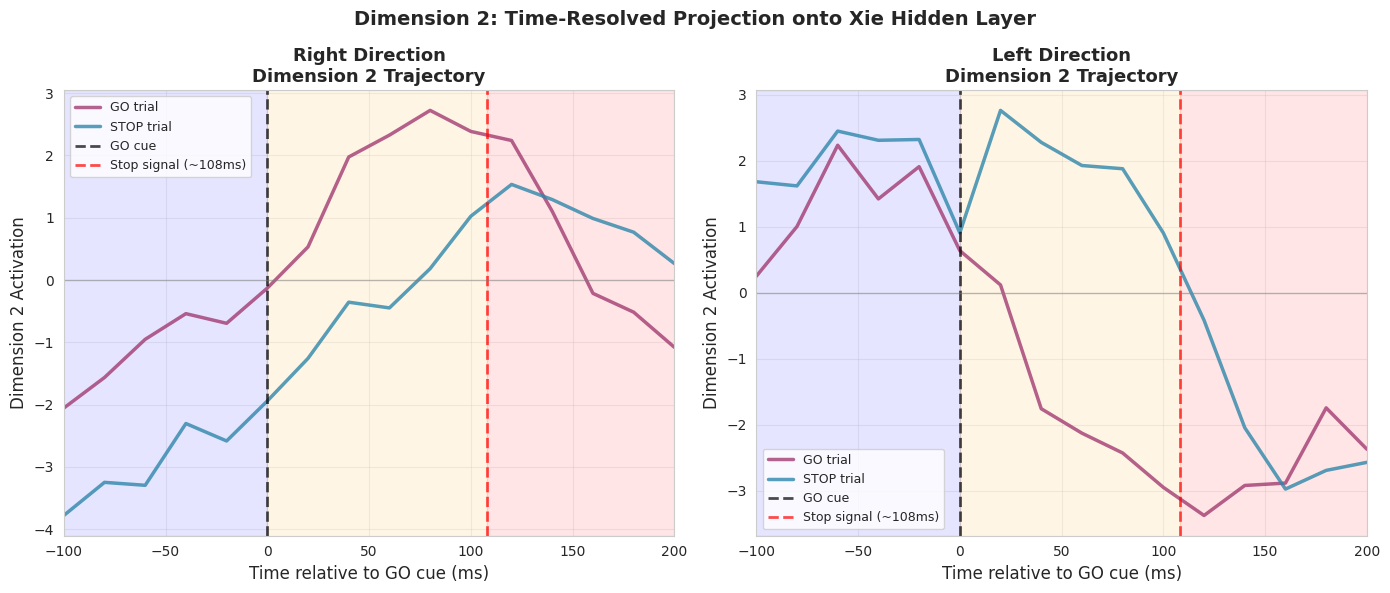

In [10]:
# Plot Dimension 2 time course for GO vs STOP trials
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get projection results
    go_time = projection_results_2d[direction]['go_time']
    go_proj_2d = projection_results_2d[direction]['go_proj_2d']
    stop_time = projection_results_2d[direction]['stop_time']
    stop_proj_2d = projection_results_2d[direction]['stop_proj_2d']
    
    # Extract Dimension 2 (index 1)
    go_dim2 = go_proj_2d[:, 1] if go_proj_2d is not None else None
    stop_dim2 = stop_proj_2d[:, 1] if stop_proj_2d is not None else None
    
    # Get mean_ssd
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Plot GO trial
    if go_dim2 is not None:
        ax.plot(go_time, go_dim2, linewidth=2.5, label='GO trial', 
                color='#A23B72', alpha=0.8)
    
    # Plot STOP trial
    if stop_dim2 is not None:
        ax.plot(stop_time, stop_dim2, linewidth=2.5, label='STOP trial', 
                color='#2E86AB', alpha=0.8)
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, 
               label='GO cue', alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, 
               label=f'Stop signal (~{mean_ssd:.0f}ms)', alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.1, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.1, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.1, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.1, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=12)
    ax.set_ylabel('Dimension 2 Activation', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nDimension 2 Trajectory', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle('Dimension 2: Time-Resolved Projection onto Xie Hidden Layer', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 8. 2D Trajectory Visualization

## 8.1 Single Exemplar Trials in 2D Space

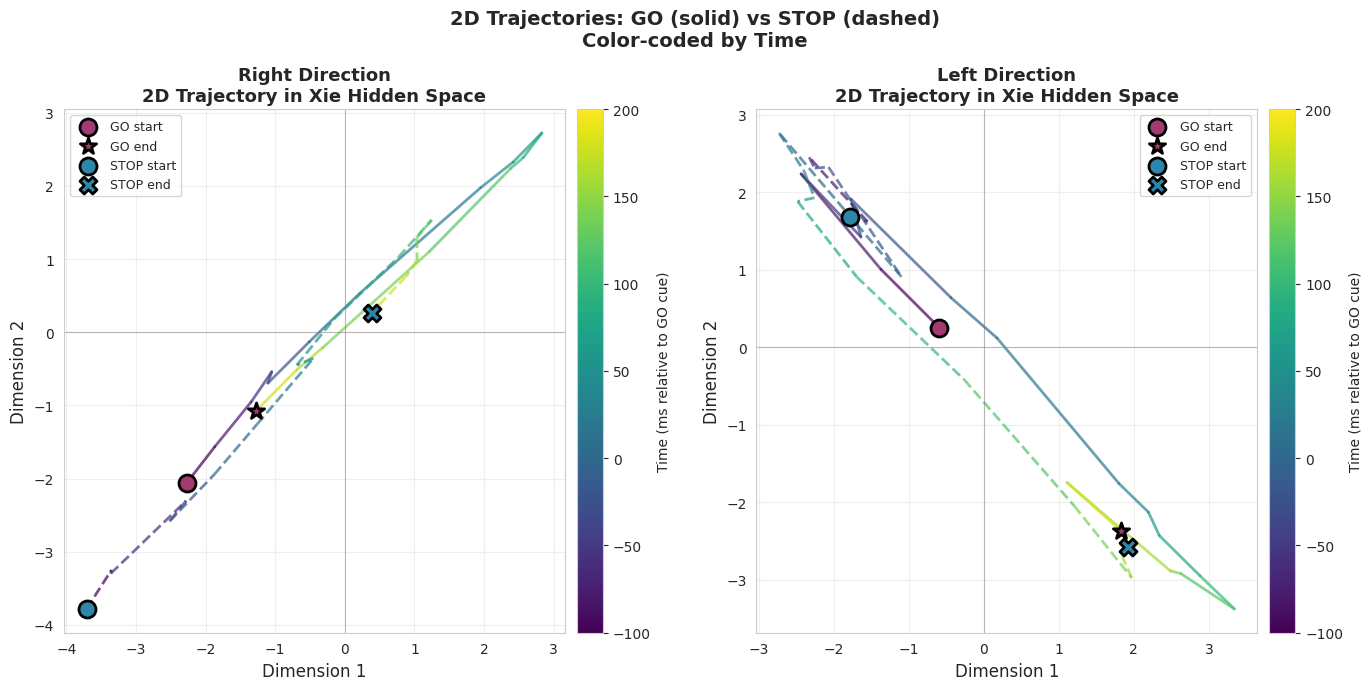

In [11]:
# Plot 2D trajectories for exemplar GO vs STOP trials
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get projection results
    go_time = projection_results_2d[direction]['go_time']
    go_proj_2d = projection_results_2d[direction]['go_proj_2d']
    stop_time = projection_results_2d[direction]['stop_time']
    stop_proj_2d = projection_results_2d[direction]['stop_proj_2d']
    
    # Extract dimensions
    go_dim1 = go_proj_2d[:, 0]
    go_dim2 = go_proj_2d[:, 1]
    stop_dim1 = stop_proj_2d[:, 0]
    stop_dim2 = stop_proj_2d[:, 1]
    
    # Get mean_ssd
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Color code by time
    colors = plt.cm.viridis(np.linspace(0, 1, len(go_time)))
    
    # Plot GO trajectory
    for i in range(len(go_time) - 1):
        ax.plot(go_dim1[i:i+2], go_dim2[i:i+2], 
                color=colors[i], linewidth=2, alpha=0.7)
    ax.scatter(go_dim1[0], go_dim2[0], s=150, marker='o', 
               color='#A23B72', edgecolor='black', linewidth=2, 
               label='GO start', zorder=5)
    ax.scatter(go_dim1[-1], go_dim2[-1], s=150, marker='*', 
               color='#A23B72', edgecolor='black', linewidth=2, 
               label='GO end', zorder=5)
    
    # Plot STOP trajectory
    for i in range(len(stop_time) - 1):
        ax.plot(stop_dim1[i:i+2], stop_dim2[i:i+2], 
                color=colors[i], linewidth=2, alpha=0.7, linestyle='--')
    ax.scatter(stop_dim1[0], stop_dim2[0], s=150, marker='o', 
               color='#2E86AB', edgecolor='black', linewidth=2, 
               label='STOP start', zorder=5)
    ax.scatter(stop_dim1[-1], stop_dim2[-1], s=150, marker='X', 
               color='#2E86AB', edgecolor='black', linewidth=2, 
               label='STOP end', zorder=5)
    
    # Add colorbar for time
    sm = plt.cm.ScalarMappable(cmap='viridis', 
                               norm=plt.Normalize(vmin=TIME_WINDOW[0], 
                                                 vmax=TIME_WINDOW[1]))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Time (ms relative to GO cue)', fontsize=10)
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\n2D Trajectory in Xie Hidden Space', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.suptitle('2D Trajectories: GO (solid) vs STOP (dashed)\nColor-coded by Time', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 9. Population Average 2D Trajectories

In [12]:
# Compute 2D projections for all STOP and matched GO trials
population_projections_2d = {}

for direction in directions:
    info = exemplar_trials[direction]
    
    # Get all STOP trials
    stop_trial_numbers = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    # Get all GO trials from test set
    test_meta = normalized_datasets[direction]['meta_test']
    go_trial_numbers = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    # Match GO trials to STOP trials
    n_stop = len(stop_trial_numbers)
    if len(go_trial_numbers) >= n_stop:
        np.random.seed(42)
        selected_go_trials = np.random.choice(go_trial_numbers, size=n_stop, replace=False)
    else:
        selected_go_trials = go_trial_numbers
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  STOP trials: {n_stop}")
    print(f"  Selected GO trials: {len(selected_go_trials)}")
    
    # Compute projections for all STOP trials
    stop_projections_2d = []
    for trial_num in stop_trial_numbers:
        time_bins, proj_2d = compute_time_resolved_2d_projection(
            session_data, trial_num, direction,
            info['W_weights'], info['W_bias'],
            info['cell_ids'], info['train_mean'], info['train_std'],
            time_window=TIME_WINDOW, bin_size=BIN_SIZE, step_size=STEP_SIZE
        )
        if proj_2d is not None:
            stop_projections_2d.append(proj_2d)
    
    # Compute projections for all selected GO trials
    go_projections_2d = []
    for trial_num in selected_go_trials:
        time_bins, proj_2d = compute_time_resolved_2d_projection(
            session_data, trial_num, direction,
            info['W_weights'], info['W_bias'],
            info['cell_ids'], info['train_mean'], info['train_std'],
            time_window=TIME_WINDOW, bin_size=BIN_SIZE, step_size=STEP_SIZE
        )
        if proj_2d is not None:
            go_projections_2d.append(proj_2d)
    
    # Convert to arrays
    stop_projections_2d = np.array(stop_projections_2d)  # Shape: (n_trials, n_bins, 2)
    go_projections_2d = np.array(go_projections_2d)      # Shape: (n_trials, n_bins, 2)
    
    # Compute mean and SEM for each dimension
    stop_mean = stop_projections_2d.mean(axis=0)  # Shape: (n_bins, 2)
    stop_sem = stop_projections_2d.std(axis=0) / np.sqrt(len(stop_projections_2d))
    
    go_mean = go_projections_2d.mean(axis=0)  # Shape: (n_bins, 2)
    go_sem = go_projections_2d.std(axis=0) / np.sqrt(len(go_projections_2d))
    
    population_projections_2d[direction] = {
        'time_bins': time_bins,
        'stop_mean': stop_mean,
        'stop_sem': stop_sem,
        'stop_n': len(stop_projections_2d),
        'go_mean': go_mean,
        'go_sem': go_sem,
        'go_n': len(go_projections_2d),
        'stop_all': stop_projections_2d,
        'go_all': go_projections_2d
    }
    
    print(f"  Successfully computed projections for {len(stop_projections_2d)} STOP and {len(go_projections_2d)} GO trials")

print("\n✓ Population 2D projections computed")


Right Direction:
  STOP trials: 13
  Selected GO trials: 13
  Successfully computed projections for 13 STOP and 13 GO trials

Left Direction:
  STOP trials: 11
  Selected GO trials: 11
  Successfully computed projections for 11 STOP and 11 GO trials

✓ Population 2D projections computed


## 9.1 Population Average: 2D Trajectories with SEM

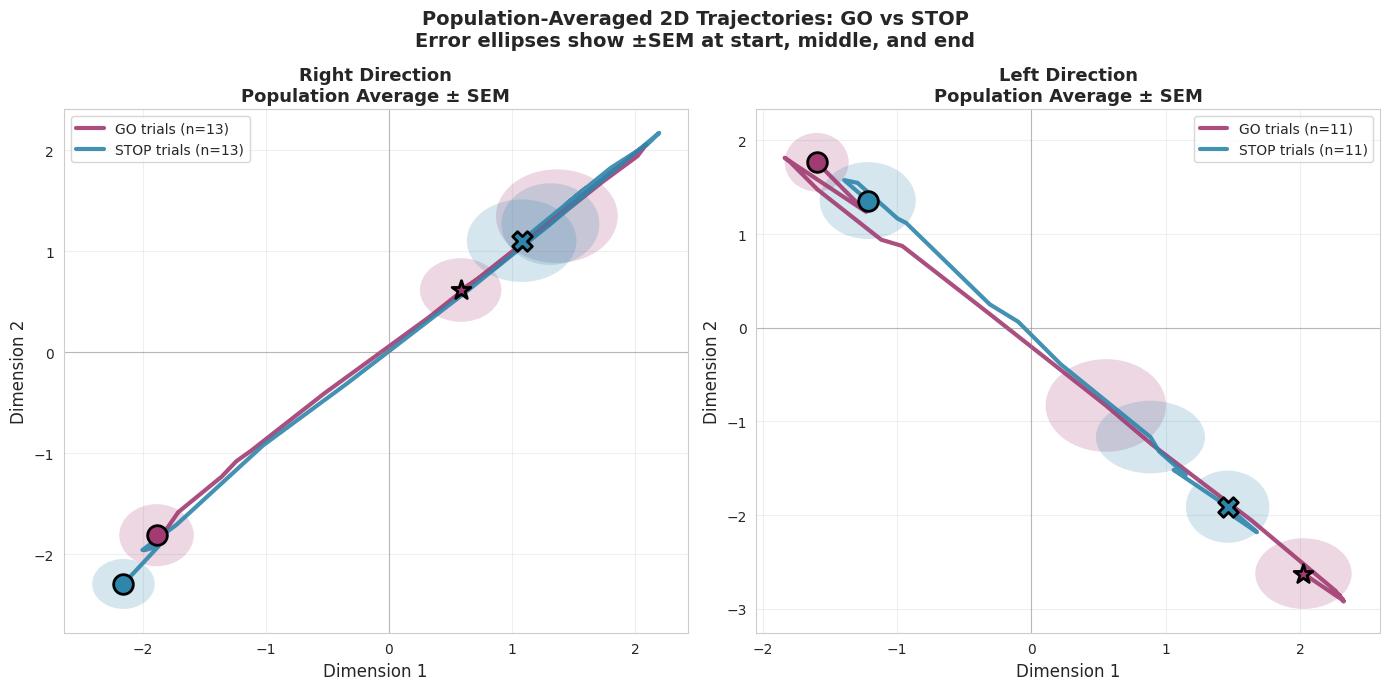

In [13]:
# Plot population average 2D trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get population data
    pop_data = population_projections_2d[direction]
    time_bins = pop_data['time_bins']
    
    stop_mean = pop_data['stop_mean']  # Shape: (n_bins, 2)
    stop_sem = pop_data['stop_sem']
    stop_n = pop_data['stop_n']
    
    go_mean = pop_data['go_mean']  # Shape: (n_bins, 2)
    go_sem = pop_data['go_sem']
    go_n = pop_data['go_n']
    
    # Extract dimensions
    go_dim1 = go_mean[:, 0]
    go_dim2 = go_mean[:, 1]
    stop_dim1 = stop_mean[:, 0]
    stop_dim2 = stop_mean[:, 1]
    
    # Plot GO trajectory
    ax.plot(go_dim1, go_dim2, linewidth=3, 
            label=f'GO trials (n={go_n})', color='#A23B72', alpha=0.9)
    ax.scatter(go_dim1[0], go_dim2[0], s=200, marker='o', 
               color='#A23B72', edgecolor='black', linewidth=2, zorder=5)
    ax.scatter(go_dim1[-1], go_dim2[-1], s=200, marker='*', 
               color='#A23B72', edgecolor='black', linewidth=2, zorder=5)
    
    # Plot STOP trajectory
    ax.plot(stop_dim1, stop_dim2, linewidth=3, 
            label=f'STOP trials (n={stop_n})', color='#2E86AB', alpha=0.9)
    ax.scatter(stop_dim1[0], stop_dim2[0], s=200, marker='o', 
               color='#2E86AB', edgecolor='black', linewidth=2, zorder=5)
    ax.scatter(stop_dim1[-1], stop_dim2[-1], s=200, marker='X', 
               color='#2E86AB', edgecolor='black', linewidth=2, zorder=5)
    
    # Add error ellipses at key time points (start, mid, end)
    from matplotlib.patches import Ellipse
    key_points = [0, len(time_bins)//2, -1]
    
    for kp in key_points:
        # GO error ellipse
        go_ellipse = Ellipse((go_dim1[kp], go_dim2[kp]), 
                            width=2*go_sem[kp, 0], height=2*go_sem[kp, 1],
                            facecolor='#A23B72', alpha=0.2, edgecolor='none')
        ax.add_patch(go_ellipse)
        
        # STOP error ellipse
        stop_ellipse = Ellipse((stop_dim1[kp], stop_dim2[kp]), 
                              width=2*stop_sem[kp, 0], height=2*stop_sem[kp, 1],
                              facecolor='#2E86AB', alpha=0.2, edgecolor='none')
        ax.add_patch(stop_ellipse)
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nPopulation Average ± SEM', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.suptitle('Population-Averaged 2D Trajectories: GO vs STOP\nError ellipses show ±SEM at start, middle, and end', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9.2 Population Average: All Individual Trials in 2D Space

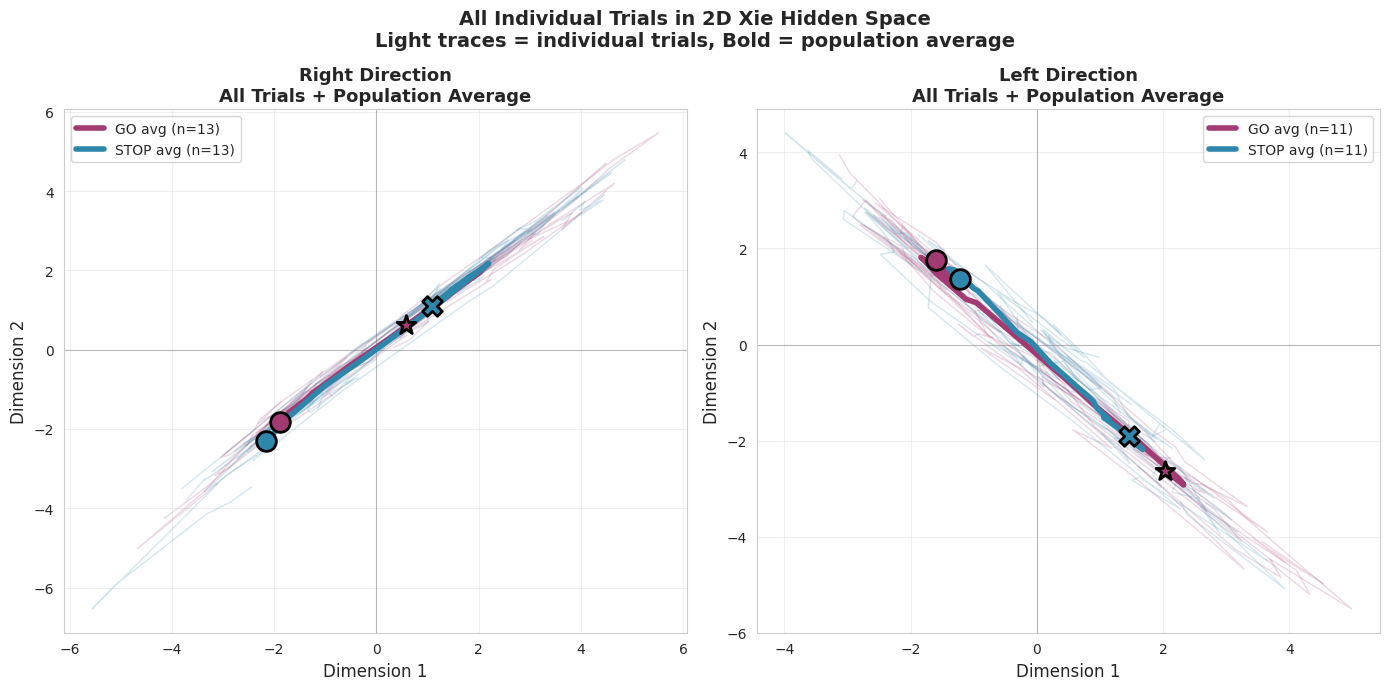

In [14]:
# Plot all individual trials in 2D space with population average
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get population data
    pop_data = population_projections_2d[direction]
    time_bins = pop_data['time_bins']
    
    stop_all = pop_data['stop_all']  # Shape: (n_trials, n_bins, 2)
    go_all = pop_data['go_all']      # Shape: (n_trials, n_bins, 2)
    
    stop_mean = pop_data['stop_mean']
    go_mean = pop_data['go_mean']
    
    # Plot individual GO trials
    for trial_idx in range(len(go_all)):
        go_dim1 = go_all[trial_idx, :, 0]
        go_dim2 = go_all[trial_idx, :, 1]
        ax.plot(go_dim1, go_dim2, color='#A23B72', alpha=0.2, linewidth=1)
    
    # Plot individual STOP trials
    for trial_idx in range(len(stop_all)):
        stop_dim1 = stop_all[trial_idx, :, 0]
        stop_dim2 = stop_all[trial_idx, :, 1]
        ax.plot(stop_dim1, stop_dim2, color='#2E86AB', alpha=0.2, linewidth=1)
    
    # Plot population averages on top
    go_dim1_mean = go_mean[:, 0]
    go_dim2_mean = go_mean[:, 1]
    ax.plot(go_dim1_mean, go_dim2_mean, linewidth=4, 
            label=f'GO avg (n={pop_data["go_n"]})', color='#A23B72', alpha=1, zorder=10)
    ax.scatter(go_dim1_mean[0], go_dim2_mean[0], s=200, marker='o', 
               color='#A23B72', edgecolor='black', linewidth=2, zorder=11)
    ax.scatter(go_dim1_mean[-1], go_dim2_mean[-1], s=200, marker='*', 
               color='#A23B72', edgecolor='black', linewidth=2, zorder=11)
    
    stop_dim1_mean = stop_mean[:, 0]
    stop_dim2_mean = stop_mean[:, 1]
    ax.plot(stop_dim1_mean, stop_dim2_mean, linewidth=4, 
            label=f'STOP avg (n={pop_data["stop_n"]})', color='#2E86AB', alpha=1, zorder=10)
    ax.scatter(stop_dim1_mean[0], stop_dim2_mean[0], s=200, marker='o', 
               color='#2E86AB', edgecolor='black', linewidth=2, zorder=11)
    ax.scatter(stop_dim1_mean[-1], stop_dim2_mean[-1], s=200, marker='X', 
               color='#2E86AB', edgecolor='black', linewidth=2, zorder=11)
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nAll Trials + Population Average', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.suptitle('All Individual Trials in 2D Xie Hidden Space\nLight traces = individual trials, Bold = population average', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 10. Dimension-Wise Population Averages

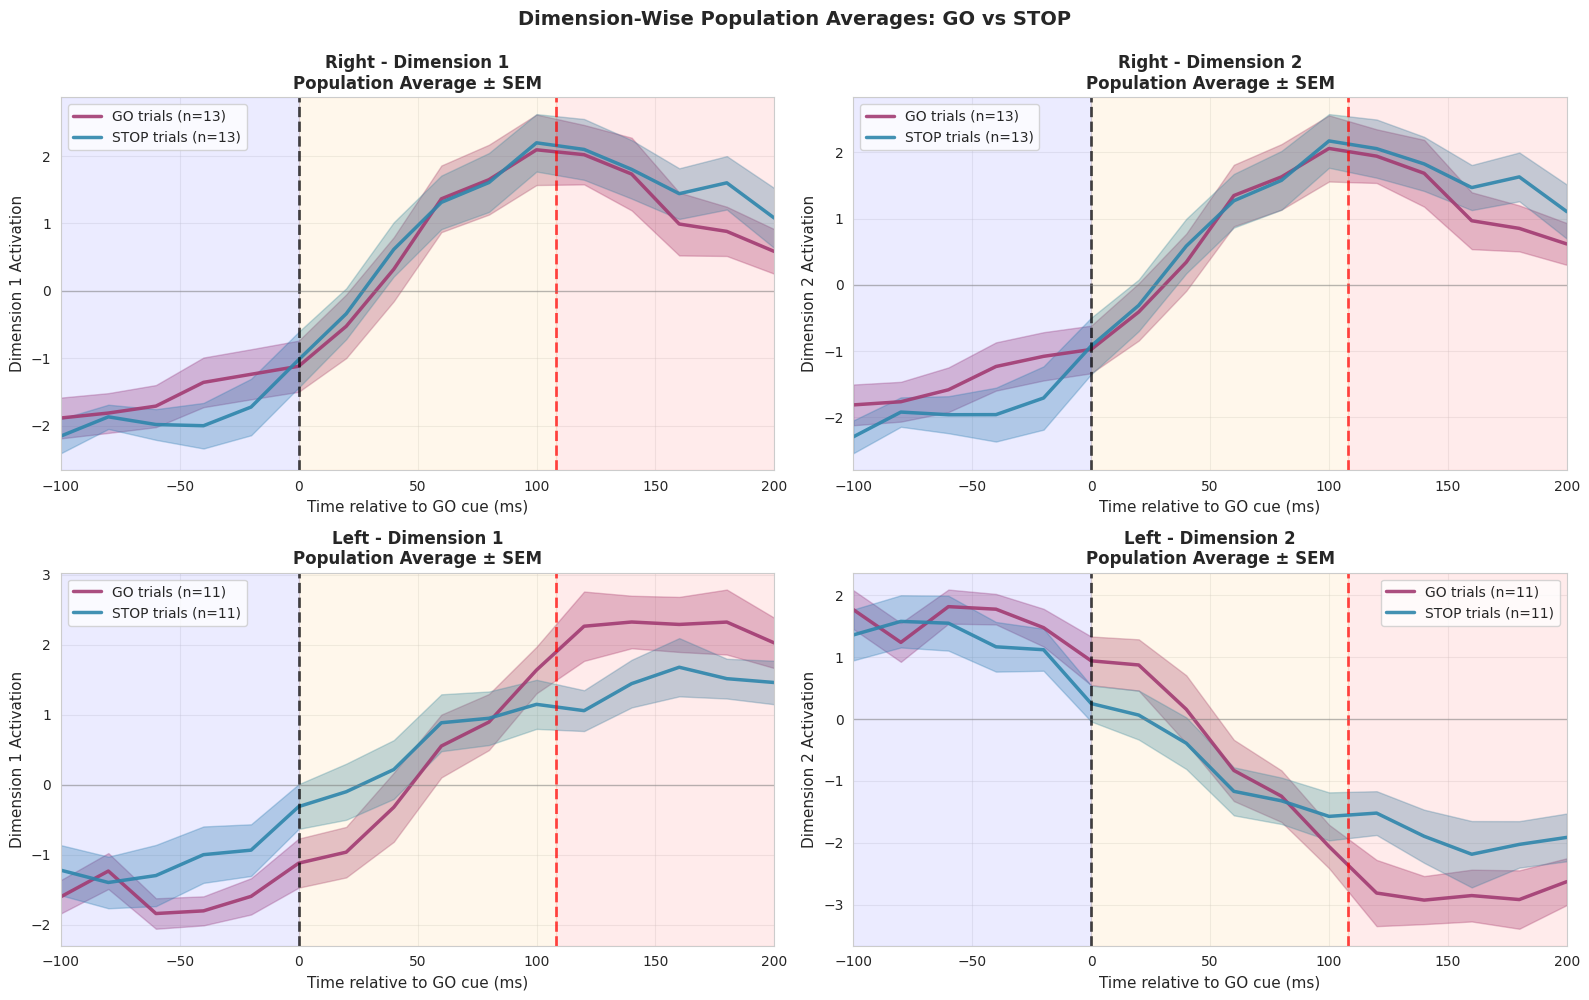

In [15]:
# Plot dimension-wise population averages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, direction in enumerate(directions):
    # Get population data
    pop_data = population_projections_2d[direction]
    time_bins = pop_data['time_bins']
    
    stop_mean = pop_data['stop_mean']  # Shape: (n_bins, 2)
    stop_sem = pop_data['stop_sem']
    stop_n = pop_data['stop_n']
    
    go_mean = pop_data['go_mean']  # Shape: (n_bins, 2)
    go_sem = pop_data['go_sem']
    go_n = pop_data['go_n']
    
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Dimension 1 (top row)
    ax = axes[idx, 0]
    
    go_dim1 = go_mean[:, 0]
    go_sem1 = go_sem[:, 0]
    ax.plot(time_bins, go_dim1, linewidth=2.5, 
            label=f'GO trials (n={go_n})', color='#A23B72', alpha=0.9)
    ax.fill_between(time_bins, go_dim1 - go_sem1, go_dim1 + go_sem1, 
                     color='#A23B72', alpha=0.3)
    
    stop_dim1 = stop_mean[:, 0]
    stop_sem1 = stop_sem[:, 0]
    ax.plot(time_bins, stop_dim1, linewidth=2.5, 
            label=f'STOP trials (n={stop_n})', color='#2E86AB', alpha=0.9)
    ax.fill_between(time_bins, stop_dim1 - stop_sem1, stop_dim1 + stop_sem1, 
                     color='#2E86AB', alpha=0.3)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Dimension 1 Activation', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Dimension 1\nPopulation Average ± SEM', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)
    
    # Dimension 2 (bottom row)
    ax = axes[idx, 1]
    
    go_dim2 = go_mean[:, 1]
    go_sem2 = go_sem[:, 1]
    ax.plot(time_bins, go_dim2, linewidth=2.5, 
            label=f'GO trials (n={go_n})', color='#A23B72', alpha=0.9)
    ax.fill_between(time_bins, go_dim2 - go_sem2, go_dim2 + go_sem2, 
                     color='#A23B72', alpha=0.3)
    
    stop_dim2 = stop_mean[:, 1]
    stop_sem2 = stop_sem[:, 1]
    ax.plot(time_bins, stop_dim2, linewidth=2.5, 
            label=f'STOP trials (n={stop_n})', color='#2E86AB', alpha=0.9)
    ax.fill_between(time_bins, stop_dim2 - stop_sem2, stop_dim2 + stop_sem2, 
                     color='#2E86AB', alpha=0.3)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Dimension 2 Activation', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Dimension 2\nPopulation Average ± SEM', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle('Dimension-Wise Population Averages: GO vs STOP', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

---

## Interpretation

### What We're Looking At:
This analysis projects neural population activity onto the **2D hidden layer** learned by the Xie decoder. This 2D space represents the internal representation that the decoder uses to distinguish FIX from GO trials.

### Key Visualizations:
1. **Dimension-wise time courses**: How each of the 2 dimensions evolves over time
2. **2D trajectory plots**: How trials move through the 2D hidden space over time
3. **Population averages**: Central tendency and variability across all trials

### What to Look For:
- **Trajectory separation**: Do GO and STOP trials follow different paths in 2D space?
- **Timing of divergence**: When do the trajectories begin to separate (if at all)?
- **Dimensionality**: Are both dimensions equally informative, or does one capture more variance?
- **Trial variability**: How consistent are individual trials within each condition?

### Critical Questions:
1. Does the 2D Xie hidden space capture stopping-related dynamics?
2. Are the trajectories consistent with inhibitory control mechanisms?
3. Which dimension (if any) best separates GO from STOP trials?

---

# 11. Sliding Window Trial Trajectories with Epoch Centroids

This section visualizes how individual trials move through the 2D hidden space using sliding time windows. We also plot **epoch centroids** representing the FIX and GO states.

## 11.1 Compute Epoch Centroids from Training Data

Compute the mean 2D projection for each epoch using the training data:
- **FIX state**: Average of first 3 epochs (FIX_early, FIX_late, GO_early)
- **GO state**: Last epoch (GO_late)

In [16]:
# Compute epoch centroids for each direction
epoch_centroids = {}

for direction in directions:
    # Get training data
    X_train = normalized_datasets[direction]['X_train']  # Shape: (n_samples, n_neurons)
    y_train = normalized_datasets[direction]['y_train']  # Shape: (n_samples,) - labels: 0=FIX, 1=GO
    
    # Get W matrix and bias
    W_weights = xie_models[direction]['W_weights']  # Shape: (2, n_neurons)
    W_bias = xie_models[direction]['W_bias']  # Shape: (2,)
    
    # Project training data to 2D space
    train_projections_2d = X_train @ W_weights.T + W_bias  # Shape: (n_samples, 2)
    
    # Separate FIX (label=0) and GO (label=1) trials
    fix_mask = y_train == 0
    go_mask = y_train == 1
    
    fix_projections = train_projections_2d[fix_mask]  # Shape: (n_fix_samples, 2)
    go_projections = train_projections_2d[go_mask]    # Shape: (n_go_samples, 2)
    
    # Compute FIX state centroid
    fix_centroid_mean = fix_projections.mean(axis=0)  # Shape: (2,)
    fix_centroid_std = fix_projections.std(axis=0)    # Shape: (2,)
    fix_centroid_sem = fix_centroid_std / np.sqrt(len(fix_projections))
    
    # Compute GO state centroid
    go_centroid_mean = go_projections.mean(axis=0)    # Shape: (2,)
    go_centroid_std = go_projections.std(axis=0)      # Shape: (2,)
    go_centroid_sem = go_centroid_std / np.sqrt(len(go_projections))
    
    epoch_centroids[direction] = {
        'FIX_state': {
            'mean': fix_centroid_mean,
            'std': fix_centroid_std,
            'sem': fix_centroid_sem,
            'n': len(fix_projections)
        },
        'GO_state': {
            'mean': go_centroid_mean,
            'std': go_centroid_std,
            'sem': go_centroid_sem,
            'n': len(go_projections)
        }
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  FIX state centroid: {fix_centroid_mean} (n={len(fix_projections)})")
    print(f"  GO state centroid: {go_centroid_mean} (n={len(go_projections)})")

print("\n✓ Epoch centroids computed")


Right Direction:
  FIX state centroid: [-2.10048372 -2.03750973] (n=128)
  GO state centroid: [1.97701239 1.92764772] (n=128)

Left Direction:
  FIX state centroid: [-1.60204748  1.82812264] (n=125)
  GO state centroid: [ 1.57097563 -1.85284883] (n=126)

✓ Epoch centroids computed


## 11.2 Compute Sliding Window Trajectories for STOP Trials

Use 108 ms sliding windows starting at -200 ms, advancing by 10 ms each step.

In [17]:
# Sliding window parameters
TRAJ_WINDOW_SIZE = 108  # ms
TRAJ_STEP_SIZE = 10     # ms
TRAJ_START_TIME = 100  # ms
TRAJ_END_TIME = 300     # ms (last window starts here)

# Compute sliding window trajectories for all STOP trials
stop_trial_trajectories = {}

for direction in directions:
    info = exemplar_trials[direction]
    
    # Get all STOP trials
    stop_trial_numbers = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Computing trajectories for {len(stop_trial_numbers)} STOP trials...")
    
    # Compute trajectory for each trial
    all_trajectories = []
    all_time_bins = None
    
    for trial_num in stop_trial_numbers:
        time_bins, proj_2d = compute_time_resolved_2d_projection(
            session_data, trial_num, direction,
            info['W_weights'], info['W_bias'],
            info['cell_ids'], info['train_mean'], info['train_std'],
            time_window=(TRAJ_START_TIME, TRAJ_END_TIME),
            bin_size=TRAJ_WINDOW_SIZE,
            step_size=TRAJ_STEP_SIZE
        )
        
        if proj_2d is not None:
            all_trajectories.append(proj_2d)
            if all_time_bins is None:
                all_time_bins = time_bins
    
    # Convert to array
    all_trajectories = np.array(all_trajectories)  # Shape: (n_trials, n_time_bins, 2)
    
    # Compute mean trajectory
    mean_trajectory = all_trajectories.mean(axis=0)  # Shape: (n_time_bins, 2)
    sem_trajectory = all_trajectories.std(axis=0) / np.sqrt(len(all_trajectories))
    
    stop_trial_trajectories[direction] = {
        'time_bins': all_time_bins,
        'all_trajectories': all_trajectories,
        'mean_trajectory': mean_trajectory,
        'sem_trajectory': sem_trajectory,
        'n_trials': len(all_trajectories)
    }
    
    print(f"  Successfully computed {len(all_trajectories)} trajectories")
    print(f"  Time bins: {len(all_time_bins)} (from {all_time_bins[0]} to {all_time_bins[-1]} ms)")

print("\n✓ Sliding window trajectories computed")


Right Direction:
  Computing trajectories for 13 STOP trials...
  Successfully computed 13 trajectories
  Time bins: 21 (from 100 to 300 ms)

Left Direction:
  Computing trajectories for 11 STOP trials...
  Successfully computed 11 trajectories
  Time bins: 21 (from 100 to 300 ms)

✓ Sliding window trajectories computed


## 11.3 Visualize: Epoch Centroids + Individual Trial Trajectories

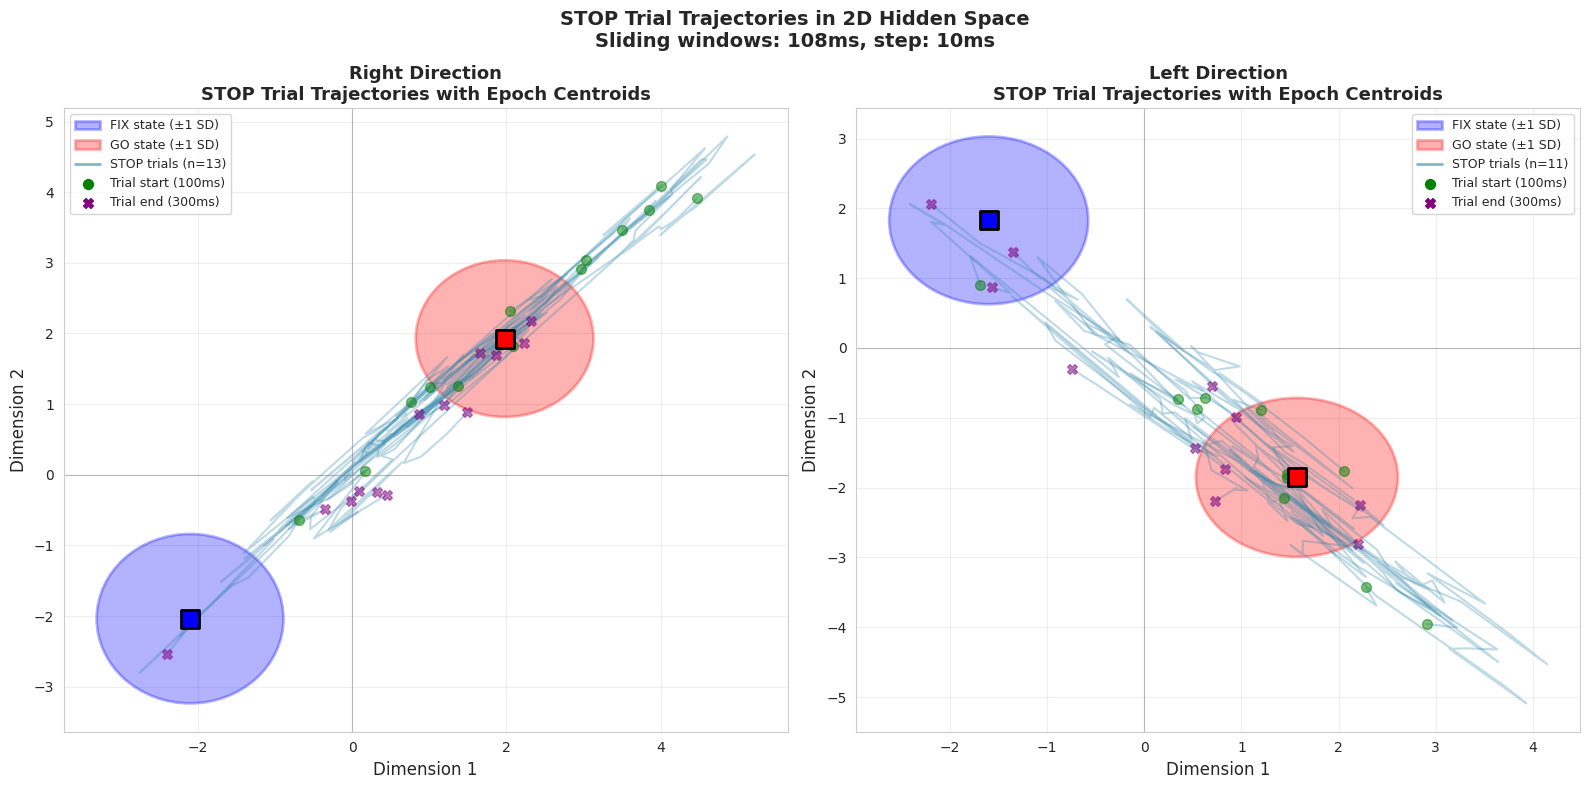

In [18]:
# Plot epoch centroids and individual trial trajectories
from matplotlib.patches import Ellipse

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get epoch centroids
    centroids = epoch_centroids[direction]
    fix_centroid = centroids['FIX_state']
    go_centroid = centroids['GO_state']
    
    # Plot FIX state centroid (ellipse)
    fix_ellipse = Ellipse(
        fix_centroid['mean'],
        width=2 * fix_centroid['std'][0],
        height=2 * fix_centroid['std'][1],
        facecolor='blue',
        alpha=0.3,
        edgecolor='blue',
        linewidth=2,
        label='FIX state (±1 SD)'
    )
    ax.add_patch(fix_ellipse)
    ax.scatter(fix_centroid['mean'][0], fix_centroid['mean'][1],
               s=150, marker='s', color='blue', edgecolor='black',
               linewidth=2, zorder=10)
    
    # Plot GO state centroid (ellipse)
    go_ellipse = Ellipse(
        go_centroid['mean'],
        width=2 * go_centroid['std'][0],
        height=2 * go_centroid['std'][1],
        facecolor='red',
        alpha=0.3,
        edgecolor='red',
        linewidth=2,
        label='GO state (±1 SD)'
    )
    ax.add_patch(go_ellipse)
    ax.scatter(go_centroid['mean'][0], go_centroid['mean'][1],
               s=150, marker='s', color='red', edgecolor='black',
               linewidth=2, zorder=10)
    
    # Plot individual STOP trial trajectories
    traj_data = stop_trial_trajectories[direction]
    all_trajectories = traj_data['all_trajectories']  # Shape: (n_trials, n_time_bins, 2)
    time_bins = traj_data['time_bins']
    
    for trial_idx in range(len(all_trajectories)):
        traj = all_trajectories[trial_idx]  # Shape: (n_time_bins, 2)
        ax.plot(traj[:, 0], traj[:, 1],
                color='#2E86AB', alpha=0.3, linewidth=1.5)
        
        # Mark start and end
        ax.scatter(traj[0, 0], traj[0, 1], s=50, marker='o',
                   color='green', alpha=0.5, zorder=5)
        ax.scatter(traj[-1, 0], traj[-1, 1], s=50, marker='X',
                   color='purple', alpha=0.5, zorder=5)
    
    # Add dummy plots for legend
    ax.plot([], [], color='#2E86AB', alpha=0.6, linewidth=2,
            label=f'STOP trials (n={traj_data["n_trials"]})')
    ax.scatter([], [], s=50, marker='o', color='green',
               label=f'Trial start ({TRAJ_START_TIME}ms)')
    ax.scatter([], [], s=50, marker='X', color='purple',
               label=f'Trial end ({TRAJ_END_TIME}ms)')
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nSTOP Trial Trajectories with Epoch Centroids',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.suptitle(f'STOP Trial Trajectories in 2D Hidden Space\nSliding windows: {TRAJ_WINDOW_SIZE}ms, step: {TRAJ_STEP_SIZE}ms',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11.4 Visualize: Mean Trajectory with Individual Trials

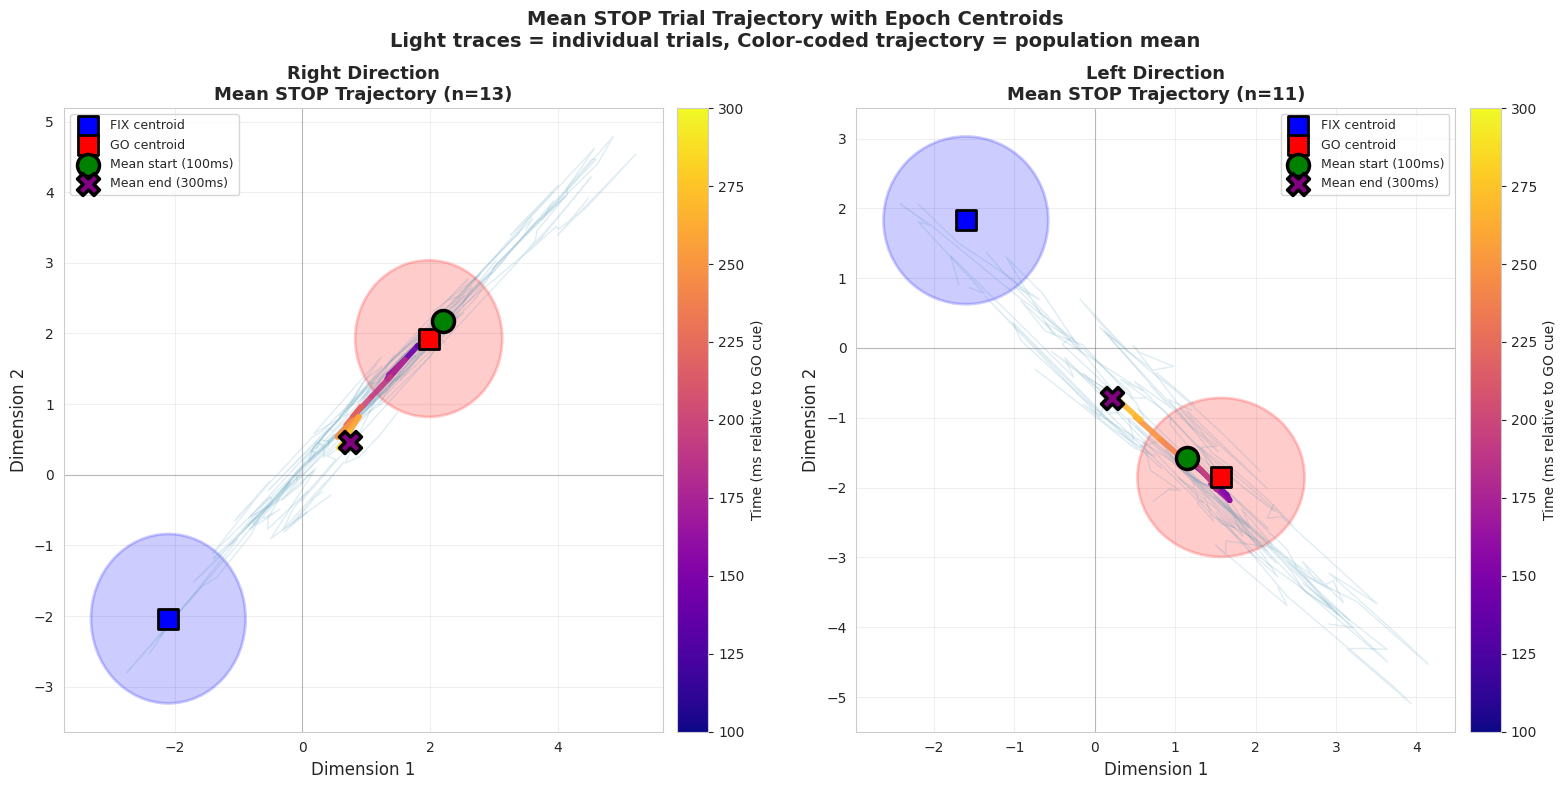

In [19]:
# Plot mean trajectory with individual trials and epoch centroids
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get epoch centroids
    centroids = epoch_centroids[direction]
    fix_centroid = centroids['FIX_state']
    go_centroid = centroids['GO_state']
    
    # Plot FIX state centroid
    fix_ellipse = Ellipse(
        fix_centroid['mean'],
        width=2 * fix_centroid['std'][0],
        height=2 * fix_centroid['std'][1],
        facecolor='blue',
        alpha=0.2,
        edgecolor='blue',
        linewidth=2
    )
    ax.add_patch(fix_ellipse)
    ax.scatter(fix_centroid['mean'][0], fix_centroid['mean'][1],
               s=200, marker='s', color='blue', edgecolor='black',
               linewidth=2, label='FIX centroid', zorder=10)
    
    # Plot GO state centroid
    go_ellipse = Ellipse(
        go_centroid['mean'],
        width=2 * go_centroid['std'][0],
        height=2 * go_centroid['std'][1],
        facecolor='red',
        alpha=0.2,
        edgecolor='red',
        linewidth=2
    )
    ax.add_patch(go_ellipse)
    ax.scatter(go_centroid['mean'][0], go_centroid['mean'][1],
               s=200, marker='s', color='red', edgecolor='black',
               linewidth=2, label='GO centroid', zorder=10)
    
    # Plot individual trials (lighter)
    traj_data = stop_trial_trajectories[direction]
    all_trajectories = traj_data['all_trajectories']
    time_bins = traj_data['time_bins']
    
    for trial_idx in range(len(all_trajectories)):
        traj = all_trajectories[trial_idx]
        ax.plot(traj[:, 0], traj[:, 1],
                color='#2E86AB', alpha=0.15, linewidth=1)
    
    # Plot mean trajectory (bold)
    mean_traj = traj_data['mean_trajectory']  # Shape: (n_time_bins, 2)
    sem_traj = traj_data['sem_trajectory']
    
    # Color-code by time
    colors = plt.cm.plasma(np.linspace(0, 1, len(time_bins)))
    
    for i in range(len(time_bins) - 1):
        ax.plot(mean_traj[i:i+2, 0], mean_traj[i:i+2, 1],
                color=colors[i], linewidth=4, alpha=0.9, zorder=8)
    
    # Mark start and end of mean trajectory
    ax.scatter(mean_traj[0, 0], mean_traj[0, 1], s=250, marker='o',
               color='green', edgecolor='black', linewidth=2.5,
               label=f'Mean start ({TRAJ_START_TIME}ms)', zorder=12)
    ax.scatter(mean_traj[-1, 0], mean_traj[-1, 1], s=250, marker='X',
               color='purple', edgecolor='black', linewidth=2.5,
               label=f'Mean end ({TRAJ_END_TIME}ms)', zorder=12)
    
    # Add colorbar for time
    sm = plt.cm.ScalarMappable(cmap='plasma',
                               norm=plt.Normalize(vmin=TRAJ_START_TIME,
                                                 vmax=TRAJ_END_TIME))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Time (ms relative to GO cue)', fontsize=10)
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nMean STOP Trajectory (n={traj_data["n_trials"]})',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.suptitle('Mean STOP Trial Trajectory with Epoch Centroids\nLight traces = individual trials, Color-coded trajectory = population mean',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11.5 Quantitative Analysis: Time of Departure from FIX Centroid

Calculate when each trial first leaves the FIX centroid region.

In [20]:
# Compute time of departure from FIX centroid for each trial
departure_analysis = {}

# Threshold: distance from FIX centroid (in units of SD)
THRESHOLD_SD = 1.5  # Consider trial has "left" if distance > 1.5 SD from centroid

for direction in directions:
    # Get epoch centroids
    # fix_centroid_mean = epoch_centroids[direction]['GO_state']['mean']
    fix_centroid_mean = epoch_centroids[direction]['FIX_state']['mean']
    fix_centroid_std = epoch_centroids[direction]['FIX_state']['std']
    # fix_centroid_std = epoch_centroids[direction]['GO_state']['std']
    
    # Compute "radius" of FIX centroid (mean of the two std components)
    fix_radius = np.mean(fix_centroid_std)
    threshold_distance = THRESHOLD_SD * fix_radius
    
    # Get trajectory data
    traj_data = stop_trial_trajectories[direction]
    all_trajectories = traj_data['all_trajectories']  # Shape: (n_trials, n_time_bins, 2)
    time_bins = traj_data['time_bins']
    
    # Compute distances from FIX centroid for each trial at each time point
    departure_times = []
    never_left = []
    
    for trial_idx in range(len(all_trajectories)):
        traj = all_trajectories[trial_idx]  # Shape: (n_time_bins, 2)
        
        # Compute Euclidean distance from FIX centroid at each time point
        distances = np.sqrt(np.sum((traj - fix_centroid_mean)**2, axis=1))  # Shape: (n_time_bins,)
        
        # Find first time point where distance exceeds threshold
        exceeds_threshold = distances > threshold_distance
        
        if np.any(exceeds_threshold):
            # Find first index where threshold is exceeded
            first_exceed_idx = np.argmin(~exceeds_threshold)  # First True
            if exceeds_threshold[first_exceed_idx]:  # Verify
                first_exceed_idx = np.argmax(exceeds_threshold)  # More reliable
            departure_time = time_bins[first_exceed_idx]
            departure_times.append(departure_time)
        else:
            # Trial never left the FIX centroid region
            never_left.append(trial_idx)
    
    # Convert to array
    departure_times = np.array(departure_times)
    
    # Compute statistics
    if len(departure_times) > 0:
        mean_departure = departure_times.mean()
        std_departure = departure_times.std()
        sem_departure = std_departure / np.sqrt(len(departure_times))
    else:
        mean_departure = np.nan
        std_departure = np.nan
        sem_departure = np.nan
    
    departure_analysis[direction] = {
        'departure_times': departure_times,
        'mean_departure': mean_departure,
        'std_departure': std_departure,
        'sem_departure': sem_departure,
        'n_departed': len(departure_times),
        'n_never_left': len(never_left),
        'n_total': len(all_trajectories),
        'threshold_distance': threshold_distance,
        'threshold_sd': THRESHOLD_SD
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  FIX centroid radius (mean std): {fix_radius:.3f}")
    print(f"  Threshold distance ({THRESHOLD_SD} SD): {threshold_distance:.3f}")
    print(f"  Trials that left FIX region: {len(departure_times)}/{len(all_trajectories)}")
    print(f"  Trials that never left: {len(never_left)}/{len(all_trajectories)}")
    if len(departure_times) > 0:
        print(f"  Mean departure time: {mean_departure:.1f} ± {std_departure:.1f} ms")
        print(f"  SEM: {sem_departure:.1f} ms")
        print(f"  Range: [{departure_times.min():.0f}, {departure_times.max():.0f}] ms")

print("\n✓ Departure time analysis complete")


Right Direction:
  FIX centroid radius (mean std): 1.205
  Threshold distance (1.5 SD): 1.807
  Trials that left FIX region: 13/13
  Trials that never left: 0/13
  Mean departure time: 100.0 ± 0.0 ms
  SEM: 0.0 ms
  Range: [100, 100] ms

Left Direction:
  FIX centroid radius (mean std): 1.113
  Threshold distance (1.5 SD): 1.669
  Trials that left FIX region: 11/11
  Trials that never left: 0/11
  Mean departure time: 101.8 ± 5.7 ms
  SEM: 1.7 ms
  Range: [100, 120] ms

✓ Departure time analysis complete


### Visualize Departure Times

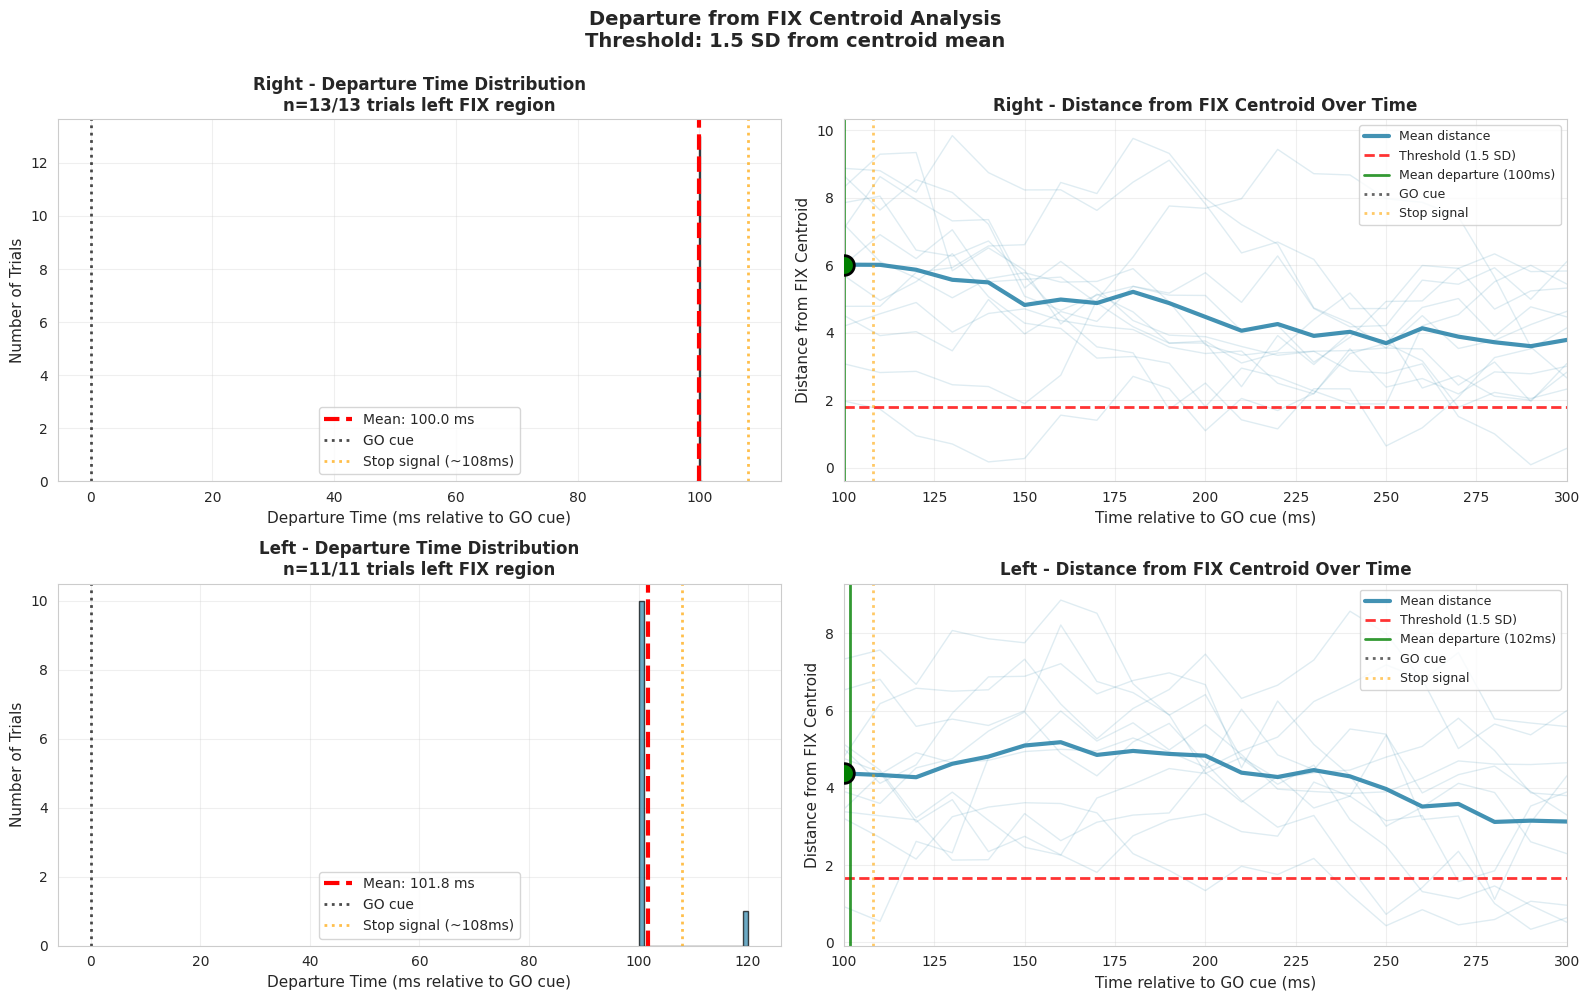

In [21]:
# Visualize departure times distribution and distance from FIX centroid over time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, direction in enumerate(directions):
    # Get data
    dep_data = departure_analysis[direction]
    traj_data = stop_trial_trajectories[direction]
    fix_centroid_mean = epoch_centroids[direction]['FIX_state']['mean']
    
    departure_times = dep_data['departure_times']
    mean_departure = dep_data['mean_departure']
    threshold_distance = dep_data['threshold_distance']
    
    all_trajectories = traj_data['all_trajectories']
    time_bins = traj_data['time_bins']
    mean_traj = traj_data['mean_trajectory']
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Top plot: Histogram of departure times
    ax = axes[idx, 0]
    
    if len(departure_times) > 0:
        ax.hist(departure_times, bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
        ax.axvline(mean_departure, color='red', linewidth=3, linestyle='--',
                   label=f'Mean: {mean_departure:.1f} ms')
        ax.axvline(0, color='black', linewidth=2, linestyle=':',
                   label='GO cue', alpha=0.7)
        ax.axvline(mean_ssd, color='orange', linewidth=2, linestyle=':',
                   label=f'Stop signal (~{mean_ssd:.0f}ms)', alpha=0.7)
    
    ax.set_xlabel('Departure Time (ms relative to GO cue)', fontsize=11)
    ax.set_ylabel('Number of Trials', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Departure Time Distribution\n'
                 f'n={dep_data["n_departed"]}/{dep_data["n_total"]} trials left FIX region',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    
    # Bottom plot: Distance from FIX centroid over time
    ax = axes[idx, 1]
    
    # Plot distance for each individual trial (light)
    for trial_idx in range(len(all_trajectories)):
        traj = all_trajectories[trial_idx]
        distances = np.sqrt(np.sum((traj - fix_centroid_mean)**2, axis=1))
        ax.plot(time_bins, distances, color='#2E86AB', alpha=0.15, linewidth=1)
    
    # Plot mean distance (bold)
    mean_distances = np.sqrt(np.sum((mean_traj - fix_centroid_mean)**2, axis=1))
    ax.plot(time_bins, mean_distances, color='#2E86AB', linewidth=3,
            label='Mean distance', alpha=0.9)
    
    # Add threshold line
    ax.axhline(threshold_distance, color='red', linewidth=2, linestyle='--',
               label=f'Threshold ({THRESHOLD_SD} SD)', alpha=0.8)
    
    # Mark mean departure time
    if not np.isnan(mean_departure):
        # Find closest time bin to mean departure
        closest_idx = np.argmin(np.abs(time_bins - mean_departure))
        ax.axvline(mean_departure, color='green', linewidth=2, linestyle='-',
                   label=f'Mean departure ({mean_departure:.0f}ms)', alpha=0.8)
        ax.scatter(time_bins[closest_idx], mean_distances[closest_idx],
                   s=200, marker='o', color='green', edgecolor='black',
                   linewidth=2, zorder=10)
    
    # Mark GO cue and stop signal
    ax.axvline(0, color='black', linewidth=2, linestyle=':',
               label='GO cue', alpha=0.6)
    ax.axvline(mean_ssd, color='orange', linewidth=2, linestyle=':',
               label=f'Stop signal', alpha=0.6)
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Distance from FIX Centroid', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Distance from FIX Centroid Over Time',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([TRAJ_START_TIME, TRAJ_END_TIME])

plt.suptitle(f'Departure from FIX Centroid Analysis\nThreshold: {THRESHOLD_SD} SD from centroid mean',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 11.6 Interpretation: Trial Trajectories Through Hidden Space

### What We're Looking At:
This analysis shows how STOP trials move through the 2D hidden space over time using **sliding time windows** (108 ms windows, advancing by 10 ms).

### Key Elements:
1. **FIX State Centroid (Blue Square + Ellipse)**:
   - Represents the average position in 2D space during fixation/pre-GO periods
   - Computed from all training samples labeled as FIX (label=0)
   - Ellipse shows ±1 SD of the training data

2. **GO State Centroid (Red Square + Ellipse)**:
   - Represents the average position during movement preparation/execution
   - Computed from all training samples labeled as GO (label=1)
   - Ellipse shows ±1 SD of the training data

3. **Individual Trial Trajectories (Light Blue Lines)**:
   - Each line shows one STOP trial's path through the 2D space
   - Green circle = trial start (-200 ms)
   - Purple X = trial end (300 ms)

4. **Mean Trajectory (Color-Coded Bold Line)**:
   - Average trajectory across all STOP trials
   - Color represents time progression

5. **Departure Time Analysis**:
   - Quantifies when trials first leave the FIX centroid region
   - Threshold: 1.5 SD from FIX centroid mean
   - Histogram shows distribution of departure times
   - Distance plot shows trajectory through the space

### Critical Questions:
1. **Do STOP trials start near the FIX centroid?** This would indicate proper fixation/baseline state.
2. **Do they move toward the GO centroid?** This would suggest partial GO preparation.
3. **Do they stop before reaching the GO centroid?** This would indicate successful inhibition.
4. **When does the trajectory diverge from a path toward GO?** This timing reveals when inhibitory control takes effect.
5. **How variable are individual trials?** High variability suggests heterogeneous stopping strategies.
6. **When do trials leave the FIX region?** The mean departure time reveals the onset of neural state transition.